# **Scatter Plot**


## Overview

We will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 132.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 130.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [pandas]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 87.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [matplotlib]


#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




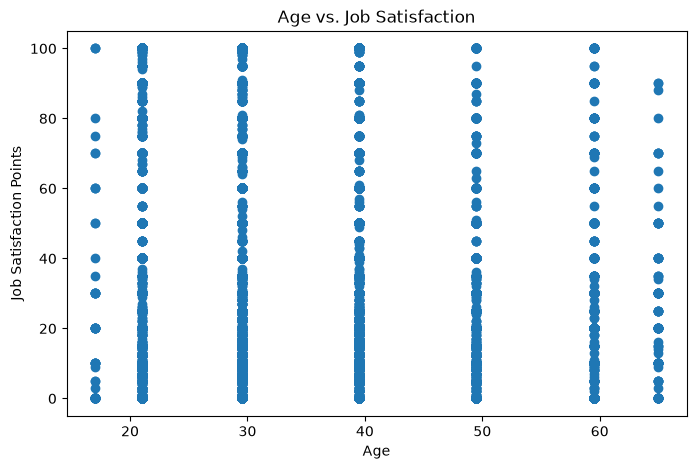

In [3]:
# Age vs. Job Satisfaction
age_map = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 65
}

plot_df = df[["Age", "JobSatPoints_6"]].copy()
plot_df["Age_numeric"] = plot_df["Age"].map(age_map)
plot_df["JobSatPoints_6"] = pd.to_numeric(plot_df["JobSatPoints_6"], errors="coerce")
plot_df = plot_df.dropna()

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["Age_numeric"], plot_df["JobSatPoints_6"])
plt.xlabel("Age")
plt.ylabel("Job Satisfaction Points")
plt.title("Age vs. Job Satisfaction")
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


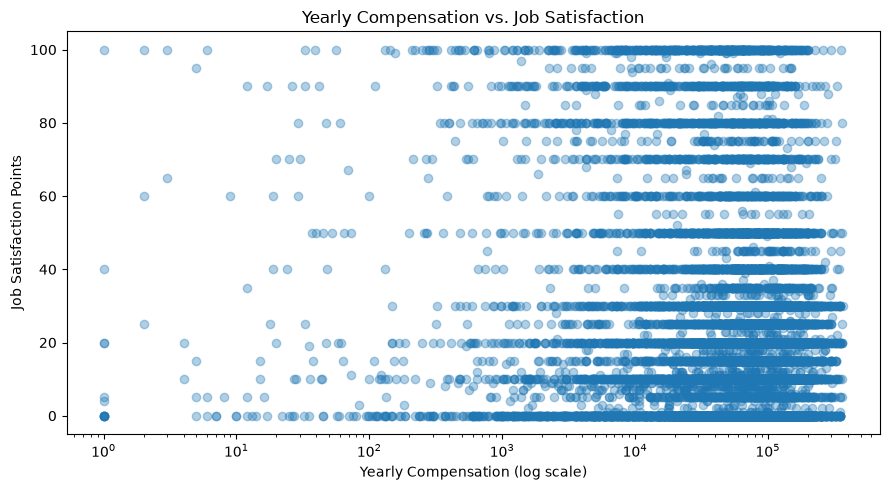

In [11]:
# Compensation vs. Job Satisfaction
plot_df = df[["ConvertedCompYearly", "JobSatPoints_6"]].copy()
plot_df["ConvertedCompYearly"] = pd.to_numeric(plot_df["ConvertedCompYearly"], errors="coerce")
plot_df["JobSatPoints_6"] = pd.to_numeric(plot_df["JobSatPoints_6"], errors="coerce")
plot_df = plot_df.dropna()
plot_df = plot_df[plot_df["ConvertedCompYearly"] > 0]
plot_df = plot_df[plot_df["ConvertedCompYearly"] < plot_df["ConvertedCompYearly"].quantile(0.99)]

plt.figure(figsize=(9, 5))
plt.scatter(plot_df["ConvertedCompYearly"], plot_df["JobSatPoints_6"], alpha=0.35)
plt.xscale("log")
plt.xlabel("Yearly Compensation (log scale)")
plt.ylabel("Job Satisfaction Points")
plt.title("Yearly Compensation vs. Job Satisfaction")
plt.tight_layout()
plt.show()

### Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


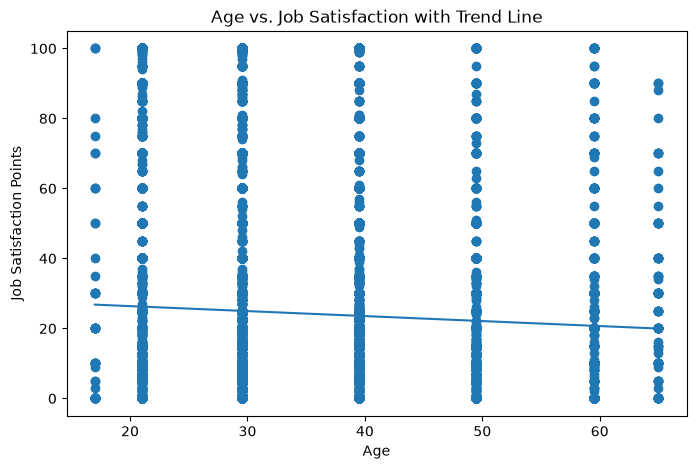

In [5]:
# Age vs. Job Satisfaction with Trend Line
plot_df = df[["Age", "JobSatPoints_6"]].copy()
plot_df["Age_numeric"] = plot_df["Age"].map(age_map)
plot_df["JobSatPoints_6"] = pd.to_numeric(plot_df["JobSatPoints_6"], errors="coerce")
plot_df = plot_df.dropna()

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["Age_numeric"], plot_df["JobSatPoints_6"])

# Regression line
m, b = pd.Series(plot_df["Age_numeric"]).pipe(lambda x: __import__("numpy").polyfit(x, plot_df["JobSatPoints_6"], 1))
x_line = pd.Series(sorted(plot_df["Age_numeric"].unique()))
y_line = m * x_line + b
plt.plot(x_line, y_line)

plt.xlabel("Age")
plt.ylabel("Job Satisfaction Points")
plt.title("Age vs. Job Satisfaction with Trend Line")
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


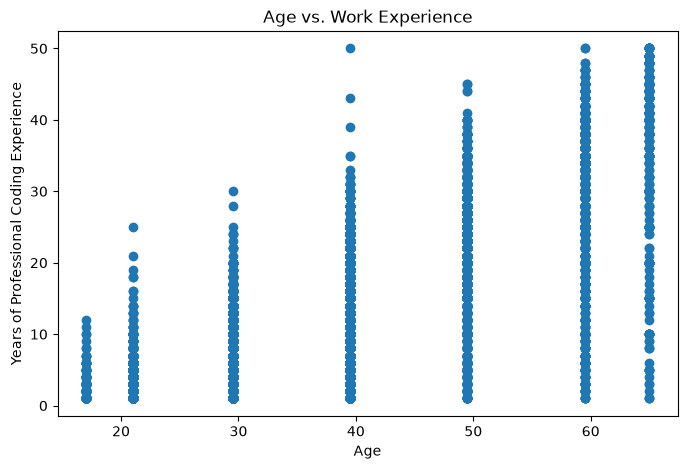

In [6]:
# Age vs. Work Experience
plot_df = df[["Age", "YearsCodePro"]].copy()
plot_df["Age_numeric"] = plot_df["Age"].map(age_map)
plot_df["YearsCodePro"] = pd.to_numeric(plot_df["YearsCodePro"], errors="coerce")
plot_df = plot_df.dropna()

plt.figure(figsize=(8, 5))
plt.scatter(plot_df["Age_numeric"], plot_df["YearsCodePro"])
plt.xlabel("Age")
plt.ylabel("Years of Professional Coding Experience")
plt.title("Age vs. Work Experience")
plt.show()

### Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


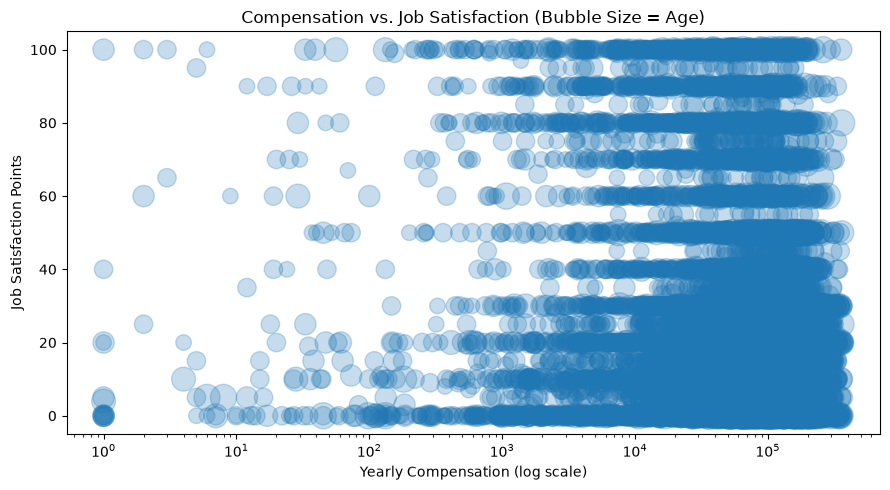

In [12]:
# Bubble Plot: Compensation vs. Job Satisfaction, bubble size = Age
plot_df = df[["Age", "ConvertedCompYearly", "JobSatPoints_6"]].copy()
plot_df["Age_numeric"] = plot_df["Age"].map(age_map)
plot_df["ConvertedCompYearly"] = pd.to_numeric(plot_df["ConvertedCompYearly"], errors="coerce")
plot_df["JobSatPoints_6"] = pd.to_numeric(plot_df["JobSatPoints_6"], errors="coerce")
plot_df = plot_df.dropna()
plot_df = plot_df[plot_df["ConvertedCompYearly"] > 0]
plot_df = plot_df[plot_df["ConvertedCompYearly"] < plot_df["ConvertedCompYearly"].quantile(0.99)]

plt.figure(figsize=(9, 5))
plt.scatter(
    plot_df["ConvertedCompYearly"],
    plot_df["JobSatPoints_6"],
    s=plot_df["Age_numeric"] * 6,
    alpha=0.25
)
plt.xscale("log")
plt.xlabel("Yearly Compensation (log scale)")
plt.ylabel("Job Satisfaction Points")
plt.title("Compensation vs. Job Satisfaction (Bubble Size = Age)")
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


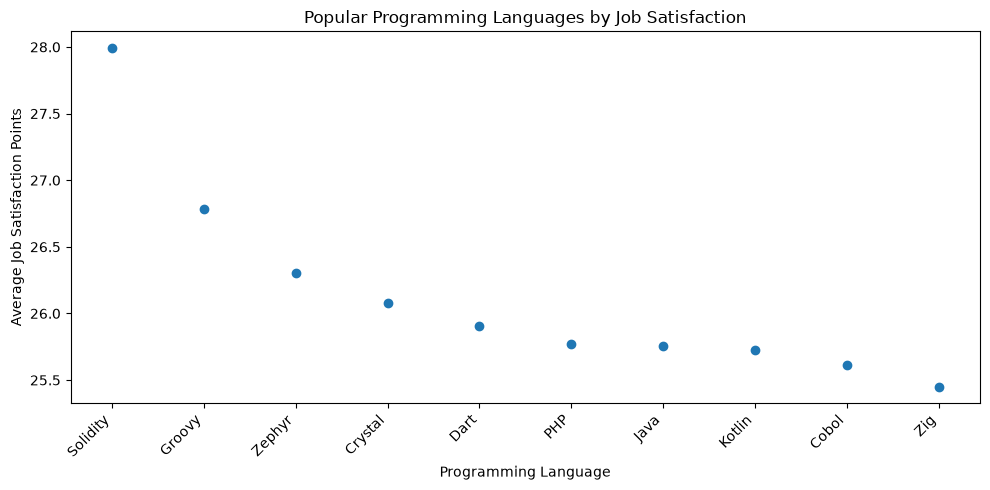

In [8]:
# Popular Programming Languages vs. Job Satisfaction
plot_df = df[["LanguageHaveWorkedWith", "JobSatPoints_6"]].copy()
plot_df["JobSatPoints_6"] = pd.to_numeric(plot_df["JobSatPoints_6"], errors="coerce")
plot_df = plot_df.dropna()
plot_df["Language"] = plot_df["LanguageHaveWorkedWith"].str.split(";")
plot_df = plot_df.explode("Language")

language_avg = plot_df.groupby("Language")["JobSatPoints_6"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.scatter(range(len(language_avg)), language_avg.values)
plt.xticks(range(len(language_avg)), language_avg.index, rotation=45, ha="right")
plt.xlabel("Programming Language")
plt.ylabel("Average Job Satisfaction Points")
plt.title("Popular Programming Languages by Job Satisfaction")
plt.tight_layout()
plt.show()

### Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


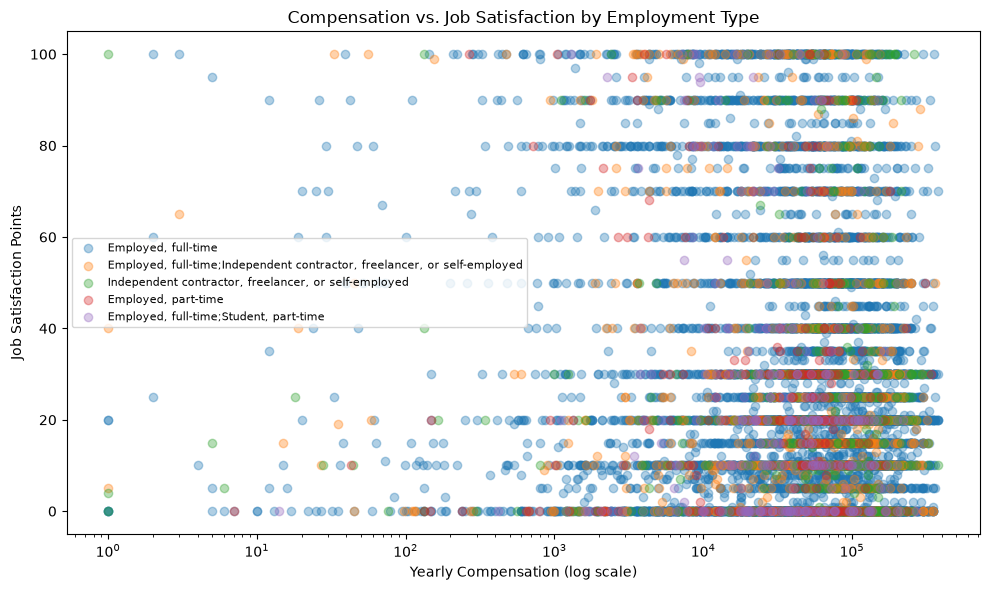

In [13]:
# Compensation vs. Job Satisfaction by Employment Type
plot_df = df[["Employment", "ConvertedCompYearly", "JobSatPoints_6"]].copy()
plot_df["ConvertedCompYearly"] = pd.to_numeric(plot_df["ConvertedCompYearly"], errors="coerce")
plot_df["JobSatPoints_6"] = pd.to_numeric(plot_df["JobSatPoints_6"], errors="coerce")
plot_df = plot_df.dropna()
plot_df = plot_df[plot_df["ConvertedCompYearly"] > 0]

# Keep the 5 most common employment types so the chart remains readable
top_employment = plot_df["Employment"].value_counts().head(5).index
plot_df = plot_df[plot_df["Employment"].isin(top_employment)]
plot_df = plot_df[plot_df["ConvertedCompYearly"] < plot_df["ConvertedCompYearly"].quantile(0.99)]

plt.figure(figsize=(10, 6))

for employment_type in top_employment:
    group = plot_df[plot_df["Employment"] == employment_type]
    plt.scatter(
        group["ConvertedCompYearly"],
        group["JobSatPoints_6"],
        label=employment_type,
        alpha=0.35
    )

plt.xscale("log")
plt.xlabel("Yearly Compensation (log scale)")
plt.ylabel("Job Satisfaction Points")
plt.title("Compensation vs. Job Satisfaction by Employment Type")
plt.legend(fontsize=8, loc="best")
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


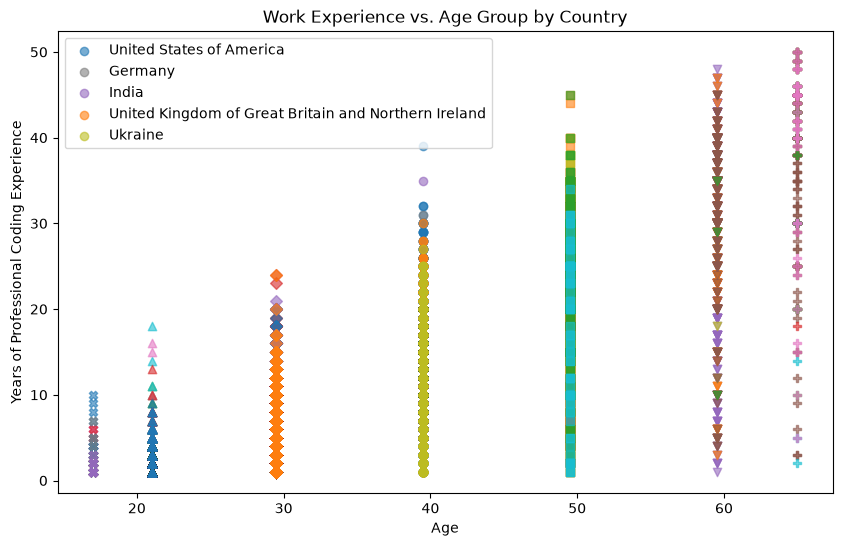

In [4]:
# Work Experience vs. Age Group by Country
plot_df = df[["Country", "Age", "YearsCodePro"]].copy()

plot_df["Age_numeric"] = plot_df["Age"].map(age_map)
plot_df["YearsCodePro"] = pd.to_numeric(plot_df["YearsCodePro"], errors="coerce")
plot_df = plot_df.dropna()

top_countries = plot_df["Country"].value_counts().head(5).index
plot_df = plot_df[plot_df["Country"].isin(top_countries)]

age_groups = plot_df["Age"].unique()
markers = ['o', 's', '^', 'D', 'v', 'P', 'X']

plt.figure(figsize=(10, 6))

for country in top_countries:
    for i, age in enumerate(age_groups):
        group = plot_df[
            (plot_df["Country"] == country) &
            (plot_df["Age"] == age)
        ]

        plt.scatter(
            group["Age_numeric"],
            group["YearsCodePro"],
            label=country if i == 0 else None,
            marker=markers[i % len(markers)],
            alpha=0.6
        )

plt.xlabel("Age")
plt.ylabel("Years of Professional Coding Experience")
plt.title("Work Experience vs. Age Group by Country")
plt.legend()
plt.show()

### Final Step: Review


With these scatter plots, we will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.
